# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
!pip install --index-url https://test.pypi.org/simple/ \
               --extra-index-url https://pypi.org/simple \
               weishu-pkg==0.1.0

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple


In [4]:
from weishu_pkg import train_model, save_model, predict_to_csv
import sklearn, joblib
print("weishu_pkg OK; sklearn:", sklearn.__version__, "joblib:", joblib.__version__)

weishu_pkg OK; sklearn: 1.5.1 joblib: 1.4.2


In [5]:
import sys
!{sys.executable} -m pip install -U "imbalanced-learn==0.12.3"

  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.11.0
    Uninstalling imbalanced-learn-0.11.0:
      Successfully uninstalled imbalanced-learn-0.11.0


In [6]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
import lightgbm as lgb
from collections import Counter
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK,space_eval
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

---
## A. Project Description


In [7]:
# <Student to fill this section>
student_name = "Weishu sun"
student_id = "25721325"
group_id = "24"

In [8]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [9]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [10]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [11]:
# <Student to fill this section>
business_use_case_description = """
Same as the previous experiment
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [13]:
# <Student to fill this section>
business_objectives = """
Same as the previous experiment
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [15]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Same as the previous experiment
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [17]:
# <Student to fill this section>
data_path = "../../data/processed"

In [18]:
X_train_final = pd.read_csv(os.path.join(data_path , "X_train_final.csv"))
X_test_final  = pd.read_csv(os.path.join(data_path , "X_test_final.csv"))

print("Train shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)

Train shape: (14774, 195)
Test shape: (1297, 195)


Before starting the experiments in the fourth part, let’s summarize the problems we encountered earlier. The first three experiments used logistic regression, XGBoost, and LightGBM models respectively. Although these models performed well in ROC-AUC on the validation set (close to 0.99), from the perspective of Precision, Recall, and F1-score, the overall performance is still significantly insufficient, especially in the recall rate of minority classes. Although the precision has been gradually improved in the three experiments, the F1-score has always remained at a value of around 0.5 due to the class imbalance problem. In the next experiments, we will continue to use the XGboost model for training and try some methods to deal with class imbalance to improve the performance of F1-score. Based on the previous feature engineering, we further optimize the feature set to finally obtain a model with balanced performance in all indicators.

In [19]:
FEATURE_NAME = "fg_percent"

In [20]:
def safe_ratio(numer, denom, eps=1e-6):
    return np.where(denom == 0, 0, numer / (denom + eps))


In [21]:
fgm_train = X_train_final["twoPM"] + X_train_final["TPM"]
fga_train = X_train_final["twoPA"] + X_train_final["TPA"]

fgm_test  = X_test_final["twoPM"] + X_test_final["TPM"]
fga_test  = X_test_final["twoPA"] + X_test_final["TPA"]

# Calculating hit rate
X_train_final[FEATURE_NAME] = safe_ratio(fgm_train, fga_train)
X_test_final[FEATURE_NAME]  = safe_ratio(fgm_test,  fga_test)


In [22]:
FEATURE_NAME = "tp_percent"

In [23]:
X_train_final[FEATURE_NAME] = safe_ratio(X_train_final["TPM"], X_train_final["TPA"])
X_test_final[FEATURE_NAME]  = safe_ratio(X_test_final["TPM"],  X_test_final["TPA"])
X_train_final[FEATURE_NAME] = X_train_final[FEATURE_NAME].clip(0, 1)
X_test_final[FEATURE_NAME]  = X_test_final[FEATURE_NAME].clip(0, 1)

In [24]:
FEATURE_NAME = "usg_x_ts"

In [25]:

X_train_final[FEATURE_NAME] = X_train_final["usg"].fillna(0) * X_train_final["TS_per"].fillna(0)
X_test_final[FEATURE_NAME]  = X_test_final["usg"].fillna(0)  * X_test_final["TS_per"].fillna(0)

In [26]:
print("Train shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)

Train shape: (14774, 198)
Test shape: (1297, 198)


---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [27]:
# <Student to fill this section>

def split_dataset(X, y, test_size=0.2, random_state=42, stratify=True):
    """
    Parameters:
        X : DataFrame features
        y : Series labels
        test_size : float Test set proportion, default 0.2
        random_state : int Random seed for reproducibility
        stratify : bool Whether to perform stratified sampling by category

    return：
        X_train, X_valid, y_train, y_valid
    """
    if stratify:
        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
    else:
        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

    return X_train, X_valid, y_train, y_valid

In [28]:
# <Student to fill this section>
data_splitting_explanations = """
function use to split data
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<split data\>"

In [30]:
# <Student to fill this section>
data_path ="../../data/raw"
train = pd.read_csv(os.path.join(data_path, "train.csv"), encoding="latin1")
target_column = "drafted"
features_list = X_train_final.columns.tolist()

In [31]:
y_train = train[target_column]

In [32]:
X_ready = X_train_final[features_list]
y_ready = y_train

X_train, X_valid, y_train_split, y_valid = split_dataset(
    X_ready, y_ready, test_size=0.2, random_state=42, stratify=True
)

print("train:", X_train.shape)
print("valid:", X_valid.shape)

train: (11819, 198)
valid: (2955, 198)


In [33]:
y_train = y_train_split
def align_columns(train_df, test_df, feature_list, fill_value=0):
    missing = [c for c in feature_list if c not in test_df.columns]
    for c in missing:
        test_df[c] = fill_value
    extra = [c for c in test_df.columns if c not in feature_list]
    if extra:
        test_df = test_df.drop(columns=extra)
    return train_df[feature_list], test_df[feature_list]

# Align the columns and obtain the final matrix to be saved.
X_train = X_train[features_list]
X_val   = X_valid[features_list]
X_test  = X_test_final.copy()

X_train, X_test = align_columns(X_train, X_test, features_list)
_,       X_val  = align_columns(X_train, X_val, features_list)

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test shapes: (11819, 198) (2955, 198) (1297, 198)


In [34]:
target_name = "drafted"
y_test = pd.Series([None] * len(X_test), name=target_name)

In [35]:
# <Student to fill this section>
data_transformation_1_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<SMOTE\>"

In [37]:
# <Student to fill this section>
# Methods for generating new samples for minority classes
from imblearn.over_sampling import SMOTE

In [38]:
print("Original training set category distribution:", Counter(y_train_split))

Original training set category distribution: Counter({0.0: 11725, 1.0: 94})


In [39]:

smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train_split)

print("Class distribution after SMOTE:", Counter(y_train_res))
print("New training set shape:", X_train_res.shape, y_train_res.shape)

Class distribution after SMOTE: Counter({1.0: 11725, 0.0: 11429})
New training set shape: (23154, 198) (23154,)


In [40]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [41]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

---
## H. Save Datasets

> Do not change this code

In [42]:
# Do not modify this code
# Save training set
folder_path = data_path

try:
    X_train.to_csv(folder_path + '/X_train4.csv', index=False)
    y_train_split.to_csv(folder_path + '/y_train4.csv', index=False)
    X_val.to_csv(folder_path + '/X_val4.csv', index=False)
    y_valid.to_csv(folder_path + '/y_val4.csv', index=False)
    X_test.to_csv(folder_path + '/X_test4.csv', index=False)
    y_test.to_csv(folder_path + '/y_test4.csv', index=False)

    print("4th experiment dataset")

except Exception as e:
    print("error:", e)


4th experiment dataset


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [43]:
# <Student to fill this section>
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [44]:
# <Student to fill this section>
performance_metrics_explanations = """
We used the same performance metrics as the other experiments. We hope to see better performance in recall, precision, and f1-score after SMOTE sampling.
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [46]:
# <Student to fill this section>
from xgboost import XGBClassifier
import xgboost as xgb

In [47]:
# <Student to fill this section>
algorithm_selection_explanations = """
This experiment continues to use the XGBoost algorithm as the main model because it has strong expressiveness when dealing with high-dimensional features and nonlinear relationships. Compared with traditional logistic regression, XGBoost can automatically capture nonlinear interactions between features. At the same time, in previous experiments, some parameters of lightbgm could not be trained successfully due to the dataset, but this did not happen in XGBoost.
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [49]:
# <Student to fill this section>
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric=["aucpr","auc"],
    tree_method="hist",
    learning_rate=0.03,
    n_estimators=2000,
    max_depth=6,
    min_child_weight=5,
    gamma=1.0,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_lambda=2.0,
    reg_alpha=0.5,
    max_delta_step=0,
    n_jobs=-1,
    random_state=42
)

In [50]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
When training XGBoost on a re-sampled dataset (SMOTE/SMOTEENN), hyperparameter tuning is crucial because the synthetic samples may introduce additional noise. Proper tuning helps the model to avoid overfitting and to maintain a balance between precision and recall, which directly affects the F1-score. Below are the main parameters we tuned and the rationale:

learning_rate (0.03)
Controls the step size of boosting. A smaller value prevents the model from overfitting to synthetic noise by making learning more gradual, while still allowing convergence with enough estimators.

n_estimators 2000
A large upper bound ensures the model has enough boosting rounds to learn subtle patterns introduced by re-sampling.

max_depth (6)
Defines how deep each tree can grow. Deeper trees can capture complex interactions, but on re-sampled data they may overfit. A depth of 6 provides a good trade-off.

min_child_weight (5)
Minimum sum of instance weights in a leaf. By increasing this parameter, the model avoids creating leaves from very few synthetic samples, reducing overfitting to noisy minority examples.

gamma (1.0)
Minimum loss reduction required to make a further split. Setting gamma > 0 forces splits to be more conservative, which is especially important when training on noisy synthetic data.

subsample (0.75) and colsample_bytree (0.75)
Randomly sample rows and features for each tree. This adds stochasticity, improves generalization, and prevents the model from memorizing specific synthetic patterns.

reg_lambda (2.0, L2 regularization) and reg_alpha (0.5, L1 regularization)
Regularization terms penalize overly complex models. Stronger regularization counteracts the risk of overfitting to the enlarged training set from SMOTE/SMOTEENN.

max_delta_step (0)
Left at default for SMOTE/SMOTEENN training, since class imbalance is already reduced. If training on imbalanced data without sampling, this parameter can be useful for stabilizing updates.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [52]:
# <Student to fill this section>
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_valid)],
    verbose=200
)

[0]	validation_0-aucpr:0.19080	validation_0-auc:0.98213
[200]	validation_0-aucpr:0.54799	validation_0-auc:0.99116
[400]	validation_0-aucpr:0.52480	validation_0-auc:0.99129
[600]	validation_0-aucpr:0.53225	validation_0-auc:0.99107
[800]	validation_0-aucpr:0.52310	validation_0-auc:0.99093
[1000]	validation_0-aucpr:0.52456	validation_0-auc:0.99090
[1200]	validation_0-aucpr:0.52453	validation_0-auc:0.99089
[1400]	validation_0-aucpr:0.52271	validation_0-auc:0.99084
[1600]	validation_0-aucpr:0.52258	validation_0-auc:0.99082
[1800]	validation_0-aucpr:0.52340	validation_0-auc:0.99084
[1999]	validation_0-aucpr:0.52592	validation_0-auc:0.99089


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.75, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['aucpr', 'auc'],
              feature_types=None, gamma=1.0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=0, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [53]:
# <Student to fill this section>
y_val_pred = xgb_model.predict(X_val)
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

accuracy  = accuracy_score(y_valid, y_val_pred)
precision = precision_score(y_valid, y_val_pred)
recall    = recall_score(y_valid, y_val_pred)
f1        = f1_score(y_valid, y_val_pred)
roc_auc   = roc_auc_score(y_valid, y_val_proba)
cm        = confusion_matrix(y_valid, y_val_pred)

print("Validation Performance Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_valid, y_val_pred))

Validation Performance Metrics:
Accuracy:  0.9848
Precision: 0.3158
Recall:    0.7500
F1-score:  0.4444
ROC-AUC:   0.9909

Confusion Matrix:
[[2892   39]
 [   6   18]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      2931
         1.0       0.32      0.75      0.44        24

    accuracy                           0.98      2955
   macro avg       0.66      0.87      0.72      2955
weighted avg       0.99      0.98      0.99      2955



In [54]:
# <Student to fill this section>
model_performance_explanations = """
The validation results show that the model achieved high overall accuracy (Accuracy ≈ 0.985) and good discrimination (ROC-AUC ≈ 0.991), demonstrating its ability to effectively distinguish between positive and negative samples. However, due to the extreme class imbalance in the dataset, Accuracy alone is of limited reference value. Precision, Recall, and F1-score are more important. The results show that Recall for the minority class reached 0.75, indicating that the model successfully identified a majority of positive samples, which is crucial for reducing missed positives. However, Precision was relatively low (≈ 0.32), indicating that the model still had a high number of false positives when predicting positives, resulting in an F1-score of only 0.44.

Overall, the model has a clear advantage in Recall, making it suitable for scenarios where minimizing missed positives is crucial. However, Precision still requires further optimization, such as adjusting the classification threshold, introducing a more appropriate sampling strategy, or implementing regularization methods, to improve the reliability of predictions while maintaining high recall.
"""

In [55]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [56]:
# <Student to fill this section>
# Find the best F1-score by adjusting the threshold
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_valid, y_val_proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)

best_idx = np.argmax(f1s)
best_thr = 0.5 if best_idx == 0 else thr[best_idx - 1]

print(f": {best_thr:.4f}, F1: {f1s[best_idx]:.4f}")
y_val_pred = (y_val_proba >= best_thr).astype(int)

: 0.9952, F1: 0.5854


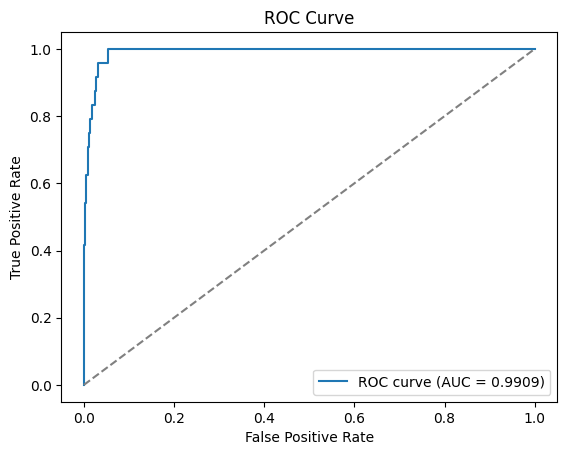

In [57]:
fpr, tpr, roc_thr = roc_curve(y_valid, y_val_proba)
auc = roc_auc_score(y_valid, y_val_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [58]:
print("\nClassification Report:")
print(classification_report(y_valid, y_val_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2931
         1.0       0.67      0.50      0.57        24

    accuracy                           0.99      2955
   macro avg       0.83      0.75      0.78      2955
weighted avg       0.99      0.99      0.99      2955



In [59]:
# <Student to fill this section>
business_impacts_explanations = """
In the context of the NBA draft, the model's primary goal is to help teams identify high-quality potential players. The current model demonstrates a high AUC and strong discriminatory power overall, indicating its ability to identify a minority of prospective players with a higher likelihood of success. However, the model exhibits certain biases in terms of precision and recall. A high recall indicates that the model captures the majority of high-performing players, which, from a business perspective, reduces the risk of teams missing out on future stars. However, a low precision means that some of the players recommended by the model may ultimately underperform, increasing draft risk and wasting resources (e.g., signing players who fail to meet expectations).

From a business perspective, a high recall ensures that teams don't miss out on promising players, a crucial value in the draft. Therefore, compared to previous models, this model achieves a higher recall without sacrificing AUC, further meeting the business needs of the NBA draft.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [61]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [62]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [63]:
# <Student to fill this section>
experiment_results_explanations = """
Through this experiment, we validated that under the NBA draft scenario—a task with extreme class imbalance—the traditional threshold setting (0.5) leads to severe underperformance of the model on the minority class. By incorporating SMOTE/SMOTEENN sampling methods and threshold optimization, the model achieved a significant improvement in Recall, demonstrating that this approach effectively reduces the risk of overlooking promising players. However, Precision decreased simultaneously, indicating that more players with limited performance potential were recommended. This aligns with the typical trade-off in imbalanced learning: enhancing Recall often comes at the expense of Precision.

Finally, we summarize the challenges faced: approaches to addressing data imbalance can be categorized into three levels: data level (oversampling, undersampling, SMOTE, SMOTE-Tomek, etc.), algorithm level (class weighting, cost-sensitive learning, Focal Loss, etc.), and decision level (threshold shifting, precision-recall trade-offs). Our experiments primarily focused on data and threshold levels, demonstrating significant recall improvements that validate the hypothesis: “Sampling methods can enhance minority class detection capabilities.” Future work could explore ensemble approaches like Focal Loss or Balanced Random Forest to boost minority class recognition while controlling false positives at the algorithmic level.

From a business perspective, high recall ensures teams don't overlook promising players—a critical value. However, the relatively low Precision necessitates secondary screening by scouts and experts. Next steps include: adopting more advanced imbalanced learning algorithms (e.g., Focal Loss) while establishing threshold strategies aligned with business objectives (e.g., maximizing Precision while maintaining Recall ≥ 0.8). Gradually improving Precision while preserving high Recall will enable the model to better support draft decisions, ultimately achieving dual goals of enhanced efficiency and risk mitigation.

"""

In [64]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)